In [3]:
### import necessary libraries
from datetime import datetime
# import geopandas as gpd
# from IPython.display import display
import matplotlib as mpl
import matplotlib.pyplot as plt 
from mpl_toolkits.axes_grid1 import make_axes_locatable
import math
import numpy as np
import os
from IPython.display import clear_output
import pandas as pd
import seaborn as sns
import scanpy as sc
import random
from adjustText import adjust_text
from sklearn.cluster import KMeans
# from sklearn.metrics import adjusted_rand_score
# from sklearn.neighbors import NearestNeighbors
# from sklearn.neighbors import KNeighborsClassifier
import warnings
from datetime import datetime

today = datetime.today().strftime('%Y-%m-%d')

pd.options.display.max_rows = 2000

import matplotlib.pyplot as plt

import matplotlib as mpl


# Ensure text remains editable in SVG

mpl.rcParams['svg.fonttype'] = 'none'  # 'none' = keep text as text objects


# Optional: improve SVG precision

mpl.rcParams['svg.hashsalt'] = ''  # consistent hashes for reproducibility

# warnings.filterwarnings("ignore") 
# sc.logging.print_header()
# sc.set_figure_params(facecolor="white", figsize=(4, 10))
# sc.settings.verbosity = 1 # errors (0), warnings (1), info (2), hints (3)
# plt.rcParams["font.family"] = "Arial"
# sns.set_style("white")

start_time = datetime.now()

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color= ['#009736','#EE2A35',"#3f488aff",
                                                    "#f79a00ff", "#cf1100ff", "#81a5bfff",
                                                    "#f9bd00ff","#547200ff", "#bfd8cdff"]) 

def print_with_elapsed_time(message):
    elapsed_time = datetime.now() - start_time
    elapsed_seconds = elapsed_time.total_seconds()
    print(f"[{elapsed_seconds:.2f} seconds] {message}")

In [1]:
from module.misc import sample_name_import

samples, samples_ids = sample_name_import('all-samples')
samples

['2505-1',
 '2505-2',
 '2670-1',
 '3159-1',
 '3160-1',
 '3160-2',
 '3159-2',
 '3161-1',
 '3159-3',
 '3161-2',
 '3159-4',
 '3161-3']

## circa-SD

In [ ]:
count = 0

for sample in samples:
    print('Start Sample :', sample)
    if sample.split('-')[0]=="circa4":
        df = pd.read_parquet(f'D:/Xenium/{sample}/transcripts.parquet',
                         filters=[("qv",">=",20)]
                         )
    else:
        df = pd.read_parquet(f'E:/Xenium_SD/{sample}/transcripts.parquet',
                         filters=[("qv",">=",20)]
                         )       

    # df['id_bis'] = "ASSIGNED"
    # df['id_bis'] = df['cell_id'].map({'UNASSIGNED':"UNASSIGNED"})
    # df['id_bis'] = df['id_bis'].fillna('ASSIGNED')
    # ass_unass = df.groupby('id_bis')['feature_name'].value_counts(sort=False)

    
    data = pd.DataFrame({'feature_name': df.feature_name.value_counts().index,'count' : df.feature_name.value_counts()})
    data.sort_index(inplace=True)

    # data["UNASSIGNED"] =  ass_unass["UNASSIGNED"]
    # data['UNASSIGNED'] = data['UNASSIGNED'].fillna(0)
    # data["ASSIGNED"] =  ass_unass["ASSIGNED"]
    # data['ASSIGNED'] = data['ASSIGNED'].fillna(0)
    # data['ratio_un'] = data['UNASSIGNED'] / data['count']
    data['type'] = data['feature_name'].apply(lambda x: x.split('_')[0])

    percentile_threshold:float = 99.5
    threshold = np.percentile(data[data['type']=="NegControlProbe"]['count'].values,percentile_threshold)
    print('threshold = ', threshold)

    data['logfoldovernoise'] = data['count'].apply(lambda x: np.log(x / threshold))
    data_gen_only = data[~(data['feature_name'].str.contains('_'))]
    print('nb of gene under threshold : ', data_gen_only[data_gen_only['logfoldovernoise']<0].shape[0])
    if count == 0:
        set_undernoise = set(data_gen_only[data_gen_only['logfoldovernoise']<0]['feature_name'].values)
    else:
        set_undernoise = set_undernoise.intersection(set(data_gen_only[data_gen_only['logfoldovernoise']<0]['feature_name'].values))

    count += 1
    print(count)

Start Sample : SD1-ZT01
threshold =  151.025
nb of gene under threshold :  496
Start Sample : SD1-ZT05
threshold =  154.58999999999997
nb of gene under threshold :  519
Start Sample : SD1-ZT09
threshold =  161.61499999999998
nb of gene under threshold :  534
Start Sample : SD1-ZT13
threshold =  154.37499999999997
nb of gene under threshold :  654
Start Sample : SD1-ZT17
threshold =  147.93499999999997
nb of gene under threshold :  657
Start Sample : SD1-ZT21
threshold =  228.04499999999996
nb of gene under threshold :  790


In [46]:
data.loc["Opn1mw","logfoldovernoise"]

-0.11633699885912151

In [39]:
len(set_undernoise)

351

In [50]:
pd.Series(list(set_undernoise)).to_csv('undernoise_circa-SD.csv')

## AD

In [6]:
count = 0

for sample in samples:
    print('Start Sample :', sample)

    df = pd.read_parquet(f'D:/Xenium/{sample}/transcripts.parquet',
                         filters=[("qv",">=",20)]
                         )       

    # df['id_bis'] = "ASSIGNED"
    # df['id_bis'] = df['cell_id'].map({'UNASSIGNED':"UNASSIGNED"})
    # df['id_bis'] = df['id_bis'].fillna('ASSIGNED')
    # ass_unass = df.groupby('id_bis')['feature_name'].value_counts(sort=False)

    
    data = pd.DataFrame({'feature_name': df.feature_name.value_counts().index,'count' : df.feature_name.value_counts()})
    data.sort_index(inplace=True)

    # data["UNASSIGNED"] =  ass_unass["UNASSIGNED"]
    # data['UNASSIGNED'] = data['UNASSIGNED'].fillna(0)
    # data["ASSIGNED"] =  ass_unass["ASSIGNED"]
    # data['ASSIGNED'] = data['ASSIGNED'].fillna(0)
    # data['ratio_un'] = data['UNASSIGNED'] / data['count']
    data['type'] = data['feature_name'].apply(lambda x: x.split('_')[0])

    percentile_threshold:float = 99.5
    threshold = np.percentile(data[data['type']=="NegControlProbe"]['count'].values,percentile_threshold)
    print('threshold = ', threshold)

    data['logfoldovernoise'] = data['count'].apply(lambda x: np.log(x / threshold))
    data_gen_only = data[~(data['feature_name'].str.contains('_'))]
    print('nb of gene under threshold : ', data_gen_only[data_gen_only['logfoldovernoise']<0].shape[0])
    if count == 0:
        set_undernoise = set(data_gen_only[data_gen_only['logfoldovernoise']<0]['feature_name'].values)
    else:
        set_undernoise = set_undernoise.intersection(set(data_gen_only[data_gen_only['logfoldovernoise']<0]['feature_name'].values))

    count += 1
    print("count = ", count)

Start Sample : 2505-1
threshold =  1413.6400000000003
nb of gene under threshold :  1
1
Start Sample : 2505-2
threshold =  1549.4900000000005
nb of gene under threshold :  1
2
Start Sample : 2670-1
threshold =  1093.6100000000001
nb of gene under threshold :  0
3
Start Sample : 3159-1
threshold =  1574.2200000000003
nb of gene under threshold :  1
4
Start Sample : 3160-1
threshold =  1855.7500000000005
nb of gene under threshold :  1
5
Start Sample : 3160-2
threshold =  2204.9400000000005
nb of gene under threshold :  1
6
Start Sample : 3159-2
threshold =  3857.120000000001
nb of gene under threshold :  1
7
Start Sample : 3161-1
threshold =  5169.42
nb of gene under threshold :  0
8
Start Sample : 3159-3
threshold =  3520.2000000000003
nb of gene under threshold :  0
9
Start Sample : 3161-2
threshold =  6169.89
nb of gene under threshold :  0
10
Start Sample : 3159-4
threshold =  5347.4900000000025
nb of gene under threshold :  1
11
Start Sample : 3161-3
threshold =  4735.150000000001


In [7]:
set_undernoise

set()

## plot

In [36]:
color = {"DeprecatedCodeword" : "blue",
         "NegControlCodeword" : 'green',
         "NegControlProbe" : "red",
         "UnassignedCodeword" : "purple"}
data['color'] = data['type'].map(color)
data['color'] = data['color'].fillna('black')

C:\Users\hcall\AppData\Local\Temp\ipykernel_19908\326485427.py:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x= data['logfoldovernoise'], y= data['ratio_un'], c=data['color'], cmap="hls", s = 2.5)


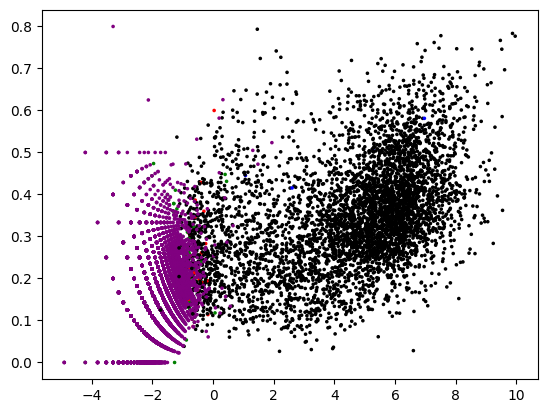

In [37]:
plt.scatter(x= data['logfoldovernoise'], y= data['ratio_un'], c=data['color'], cmap="hls", s = 2.5)

C:\Users\hcall\AppData\Local\Temp\ipykernel_19908\1569958490.py:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x= data_no_un['logfoldovernoise'], y= data_no_un['ratio_un'], c=data_no_un['color'], cmap="hls", s = 2.5)
C:\Users\hcall\AppData\Local\Temp\ipykernel_19908\1569958490.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


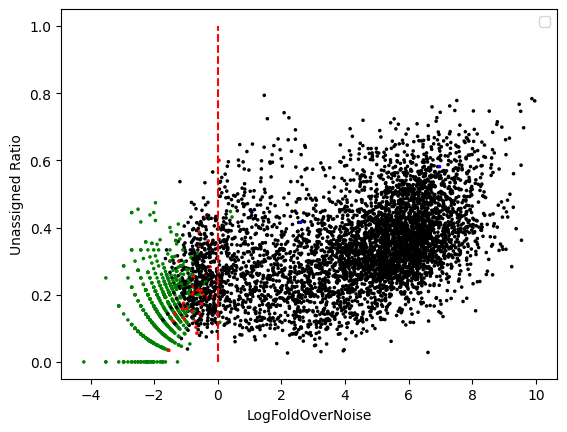

In [52]:
plt.scatter(x= data_no_un['logfoldovernoise'], y= data_no_un['ratio_un'], c=data_no_un['color'], cmap="hls", s = 2.5)
plt.vlines(x=0, ymin=0, ymax=1, linestyles='dashed', color = 'red')
plt.xlabel('LogFoldOverNoise')
plt.ylabel('Unassigned Ratio')
plt.legend()

## Plot assigned/unassigned transcripts localization

In [65]:
df = pd.read_parquet('D:/Xenium/3159-4/transcripts.parquet', filters=[("qv",">=",20), ('feature_name','=','Trem2')])
df.drop(['overlaps_nucleus','qv', 'codeword_index'],axis=1, inplace=True)
df['id_bis'] = df['cell_id'].map({'UNASSIGNED':"UNASSIGNED"})
df['id_bis'] = df['id_bis'].fillna('ASSIGNED')
df['color'] = df['id_bis'].map({'UNASSIGNED':'red','ASSIGNED':"black"})

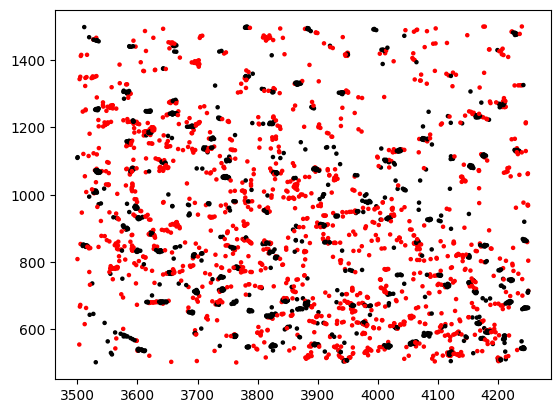

In [71]:
df_crop = df[(df['x_location'].between(3500,4250))&(df['y_location'].between(500,1500))]
# plt.figure(figsize = (10,6))
plt.scatter(x=df_crop['x_location'],y=df_crop['y_location'], color = df_crop['color'], s = 5)

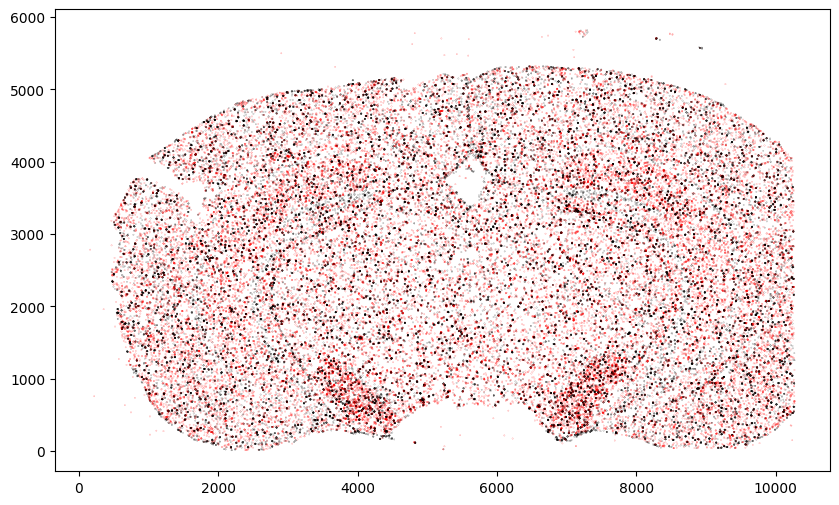

In [67]:
plt.figure(figsize = (10,6))
plt.scatter(x=df['x_location'],y=df['y_location'], color = df['color'], s = 0.01)